# <center> Обучение с учителем. Классификация. Практика

## <center> Прогнозирование оттока клиентов банка

## Постановка задачи

Теперь настало время самостоятельной работы. В рамках самостоятельной работы вам предстоит решить задачу прогнозирования оттока клиентов банка. 

> **Примечание.** Вы уже знакомились с этой задачей в модуле по визуализации («PYTHON-13. Визуализация данных») и провели небольшое исследование данных. Вы можете использовать результаты своего исследования для построения модели машинного обучения.

Напомним контекст задачи:

> Некоторый банк обратился к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов. Для этого он хочет прогнозировать вероятности оттока клиентов и определять, уйдёт ли клиент в ближайшее время. 

Итак, ранее вы провели небольшой разведывательный анализ, познакомились с данными и выявили, чем ушедшие клиенты отличаются от лояльных и как между собой связаны различные признаки, определяющие клиентов. Вы отлично справились с первой задачей, и теперь представители банка предлагают вам построить саму модель машинного обучения, которая будет прогнозировать отток клиентов. 

**Ваша задача** - построить классификатор, который позволит своевременно определять уходящих клиентов банка, оценить качество построенных моделей и проинтерпретировать результаты.

Разделим эту задачу на две части:
* В первой части мы подготовим данные для моделирования и построим простейшую модель логистической регрессии, оценим её качество и проанализируем результаты её работы.

* Во второй части мы займёмся построением моделей дерева решений и случайного леса, сравним их результаты с результатами, полученными на первом этапе, и сделаем финальный вывод.


Для начала импортируем библиотеки, которые нам понадобятся:

In [155]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import model_selection #сплитование выборки
from sklearn import preprocessing #предобработка данных
%matplotlib inline

Итак, прочитаем нашу таблицу:

In [156]:
churn_data = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas//churn.csv')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Практика: логистическая регрессия

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9:

### Задание 5.0 (не оценивается)

Для полноты задачи проведите небольшой разведывательный анализ данных. Постройте графики распределения целевого признака, диаграммы и графики, показывающие взаимосвязь между исходными признаками и целевым признаком, а также другие диаграммы, иллюстрирующие предоставленные данные. 

**Совет:** воспользуйтесь кодом, который вы писали, выполняя задания в модуле «PYTHON-13. Визуализация данных».

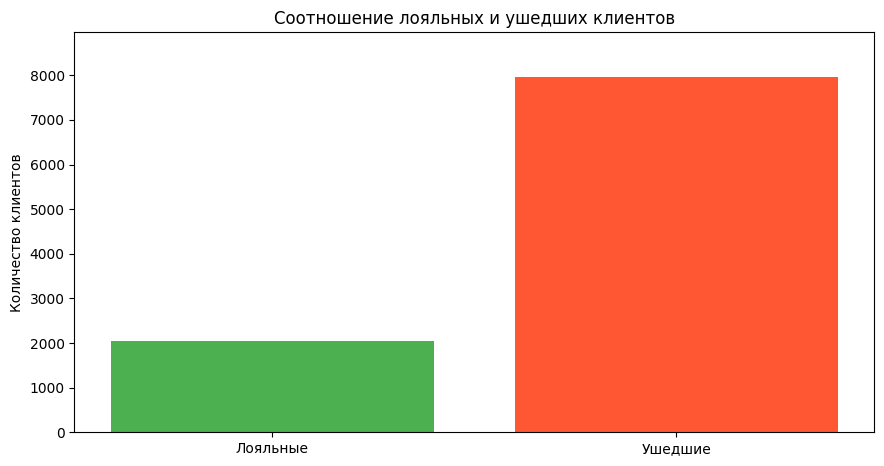

In [157]:

Zero = churn_data[churn_data['Exited'] == 0].shape[0] # Лояльный
One = churn_data[churn_data['Exited'] == 1].shape[0]  # Ушедший
values = [One,Zero]

categories = ['Лояльные', 'Ушедшие']

fig = plt.figure(figsize=(8,4))
axes = fig.add_axes([0,0,1,1])

axes.bar(categories, values, color=['#4CAF50', '#FF5733'])

plt.title('Соотношение лояльных и ушедших клиентов')
plt.ylabel('Количество клиентов')
plt.ylim(0, max(values) + 1000)
plt.show()

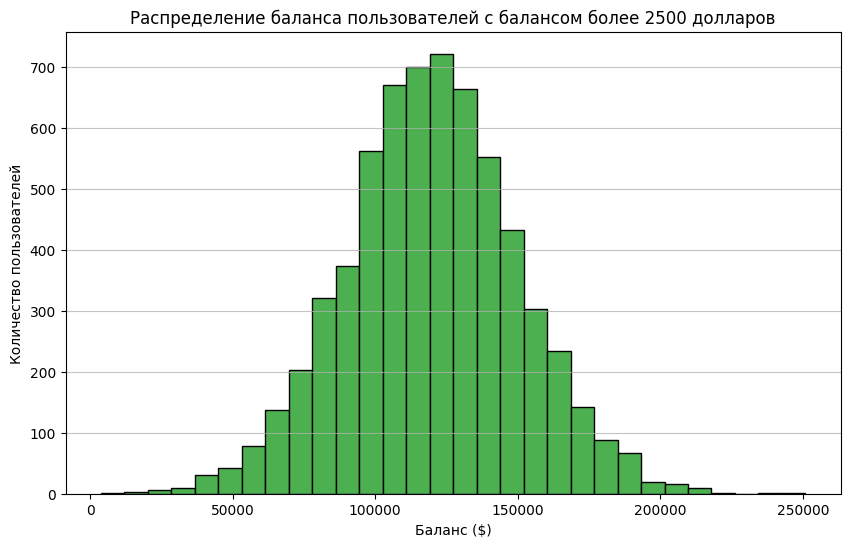

In [158]:
Balance_a = churn_data[churn_data['Balance'] > 2500]

plt.figure(figsize=(10, 6))
plt.hist(Balance_a['Balance'], bins=30, color='#4CAF50', edgecolor='black')
plt.title('Распределение баланса пользователей с балансом более 2500 долларов')
plt.xlabel('Баланс ($)')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', alpha=0.75)
plt.show()

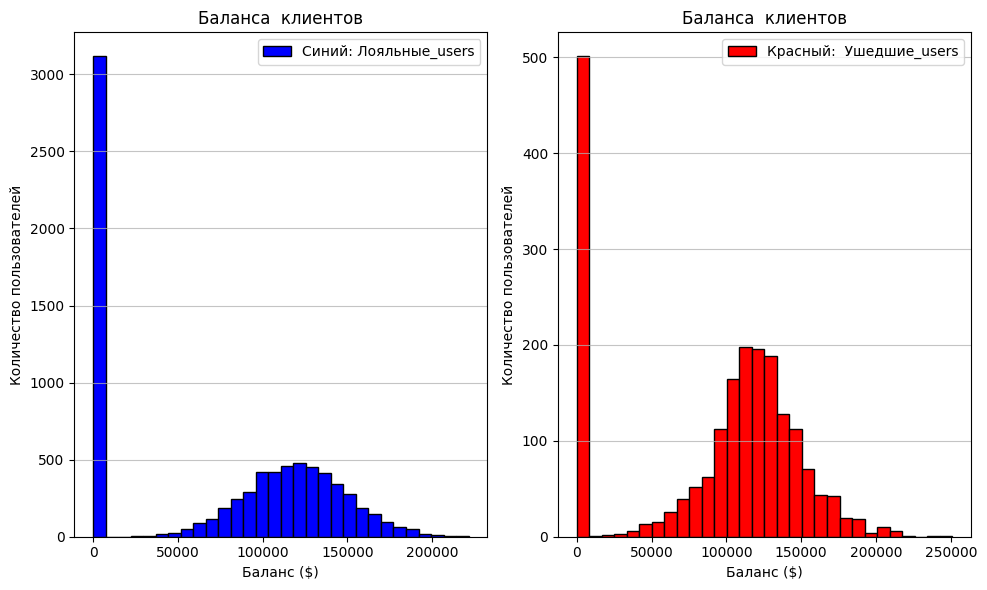

In [159]:
hist1 = churn_data[churn_data['Exited'] == 0]
hist2 = churn_data[churn_data['Exited'] == 1]


plt.figure(figsize=(10, 6))
# first paint
plt.subplot(1,2,1)
plt.hist(hist1['Balance'], bins=30, color='blue', edgecolor='black',  label='Синий: Лояльные_users')
plt.title('Баланса  клиентов')
plt.xlabel('Баланс ($)')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', alpha=0.75)
plt.legend()

# secound paint
plt.subplot(1,2,2)
plt.hist(hist2['Balance'], bins=30, color='red', edgecolor='black',  label='Красный:  Ушедшие_users' )
plt.title('Баланса  клиентов')
plt.xlabel('Баланс ($)')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', alpha=0.75)

plt.legend()

plt.tight_layout()
plt.show()


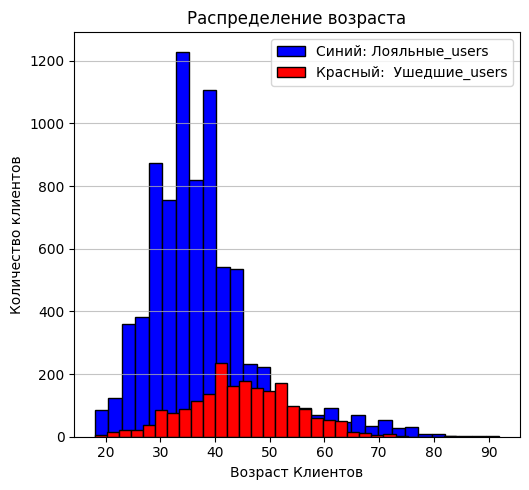

In [160]:
Closed =  churn_data[churn_data['Exited'] == 1]
Closed =  churn_data[churn_data['Exited'] == 0]

fig = plt.figure(figsize= (10,5))

plt.subplot(1,2,1)
plt.hist(Closed['Age'], bins=30, color='blue', edgecolor='black',  label='Синий: Лояльные_users')
plt.title('Распределение возраста')
plt.xlabel('Возраст Клиентов')
plt.ylabel('Количество клиентов')
plt.grid(axis='y', alpha=0.75)
plt.legend()

plt.subplot(1,2,1)
plt.hist(hist2['Age'], bins=30, color='red', edgecolor='black',  label='Красный:  Ушедшие_users' )
plt.grid(axis='y', alpha=0.75)
plt.legend()

plt.tight_layout()
plt.show()

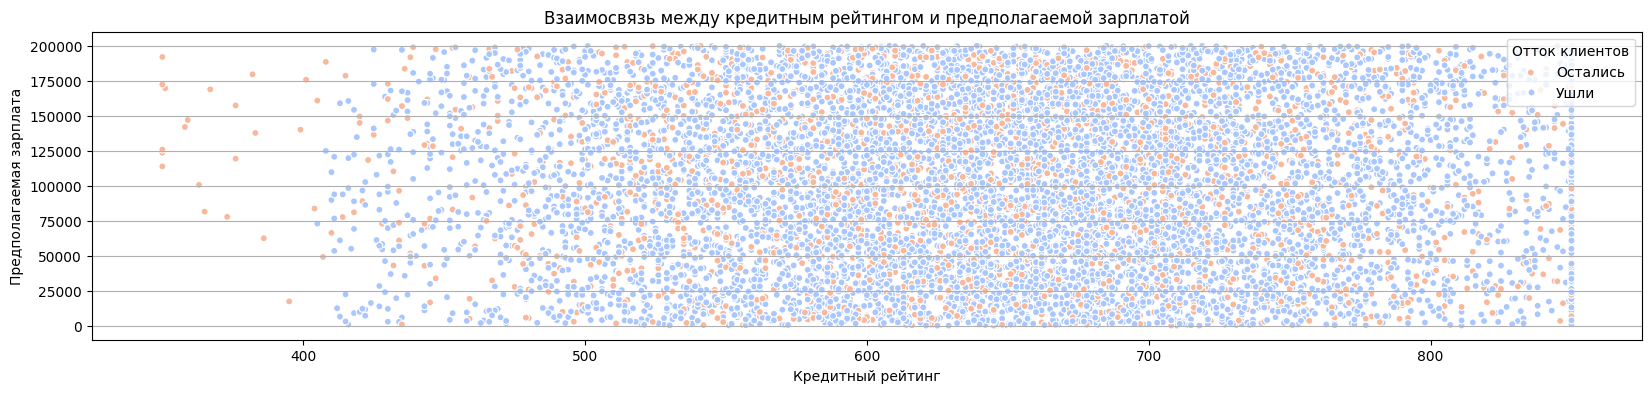

In [161]:

# Построение графика
plt.figure(figsize=(20, 4))
sns.scatterplot(data=churn_data, x='CreditScore', y='EstimatedSalary', hue='Exited', palette='coolwarm', s=100, marker = '.')
marker = '.'
# Настройка графика
plt.title('Взаимосвязь между кредитным рейтингом и предполагаемой зарплатой')
plt.xlabel('Кредитный рейтинг')
plt.ylabel('Предполагаемая зарплата')
plt.legend(title='Отток клиентов', loc='upper right', labels=['Остались', 'Ушли'])
plt.grid(axis='y', alpha= 1)

# Показать график
plt.show()

   NumOfProducts  Exited
0              1    1409
1              2     348
2              3     220
3              4      60


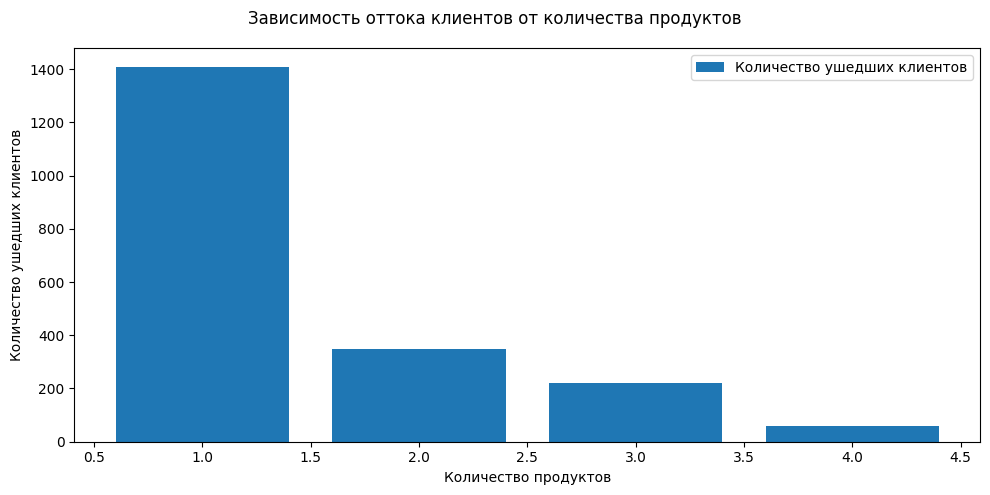

In [162]:
grouped_data = churn_data.groupby('NumOfProducts')['Exited'].sum().reset_index()
print(grouped_data)
# Создаем график
plt.figure(figsize=(10, 5))
plt.bar(grouped_data['NumOfProducts'], grouped_data['Exited'], label='Количество ушедших клиентов')

# Настройки графика
plt.xlabel("Количество продуктов")
plt.ylabel("Количество ушедших клиентов")
plt.suptitle("Зависимость оттока клиентов от количества продуктов")
plt.legend()

plt.tight_layout()
plt.show()

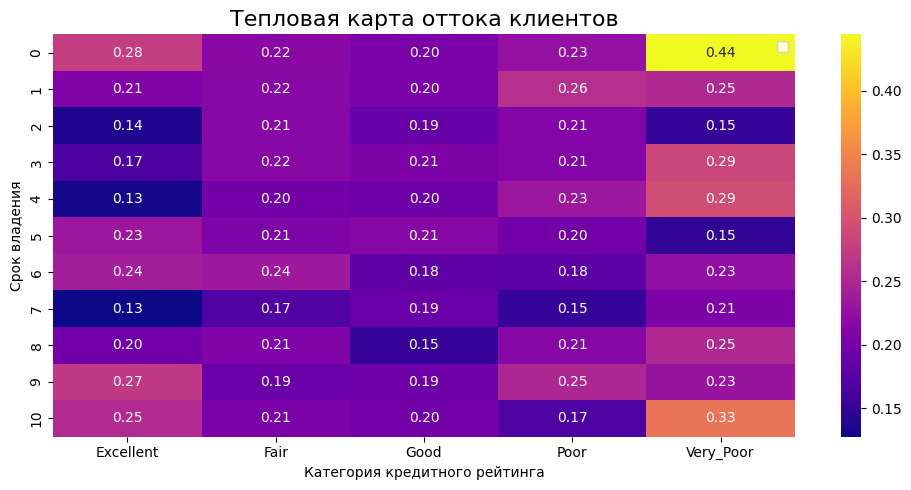

In [163]:

def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"
churn_data['CreditScoreCat'] = churn_data['CreditScore'].apply(get_credit_score_cat)
pivot = churn_data.pivot_table(values= 'Exited',
                 index='Tenure',
                 columns='CreditScoreCat',
                 fill_value= 0
                 	
)

pivot.columns = pivot.columns.astype('string')
fig = plt.figure(figsize=(10, 5))

heatmap = sns.heatmap(data=pivot, cmap='plasma', annot=True, fmt='.2f', )
heatmap.set_title('Тепловая карта оттока клиентов', fontsize=16)

plt.legend([])
plt.xlabel('Категория кредитного рейтинга')
plt.ylabel('Срок владения')




plt.tight_layout()
plt.show()
 

В модуле по визуализации мы выяснили, что отток в Германии, Франции и Испании имеет различные показатели. Исследователи, которые уже работали с этим датасетом, пришли к выводу, что наилучшее решение при работе с этими данными — строить модели индивидуально для каждой страны. Мы будем прогнозировать отток в немецком филиале банка. Давайте выделим только данные, относящиеся к Германии:

In [164]:
churn_data = churn_data[churn_data['Geography'] == 'Germany']
churn_data.shape

(2509, 15)

Сразу избавимся от заведомо неинформативных признаков: страна, номер строки, идентификатор пользователя и имя клиента.

In [165]:
churn_data = churn_data.drop(['Geography', 'RowNumber', 'CustomerId', 'Surname'], axis=1)
churn_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScoreCat
7,376,Female,29,4,115046.74,4,1,0,119346.88,1,Very_Poor
15,616,Male,45,3,143129.41,2,0,1,64327.26,0,Fair
16,653,Male,58,1,132602.88,1,1,0,5097.67,1,Fair
26,756,Male,36,2,136815.64,1,1,1,170041.95,0,Good
28,574,Female,43,3,141349.43,1,1,1,100187.43,0,Poor


Проверим, что в наших данных нет пропусков:

In [166]:
churn_data.isnull().sum()

CreditScore        0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
CreditScoreCat     0
dtype: int64

Проверим, что в наших данных нет дубликатов:

In [167]:
churn_data[churn_data.duplicated()].sum()

CreditScore          0
Gender               0
Age                  0
Tenure               0
Balance            0.0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary    0.0
Exited               0
CreditScoreCat       0
dtype: object

### Задание 5.1 (1 балл)

Давайте сделаем предобработку данных. 

Для начала расширим датасет с помощью методов Feature Engineering. Создайте следующие признаки:
* `BalanceSalaryRatio` — отношение баланса на счетах к заработной плате клиента;
* `TenureByAge` — отношение времени пользования услугами банка к возрасту клиента;
* `CreditScoreGivenAge` — отношение кредитного рейтинга к возрасту клиента.

Затем перекодируйте оставшиеся текстовые категориальные признаки в числовые бинарные столбцы.

Выведите основные статистические характеристики полученных признаков.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для создания указанных в задании признаков;
    * приведён код для кодирования категориальных признаков в числовые бинарные столбцы;
    * приведён код для расчёта основных статистических характеристик полученных признаков.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [168]:
churn_data['BalanceSalaryRatio'] = churn_data['Balance'] / (churn_data['EstimatedSalary'] + 0)
churn_data['TenureByAge'] = churn_data['Tenure'] / (churn_data['Age'] + 0)
churn_data['CreditScoreGivenAge'] = churn_data['CreditScore'] / (churn_data['Age'] + 0)
# print(churn_data['BalanceSalaryRatio'])
# print(churn_data['TenureByAge'])
# print(churn_data['CreditScoreGivenAge'])


In [169]:
# Определяем категориальные колонки
categorical_cols = churn_data.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные признаки: {categorical_cols}")
print(f"Уникальные значения:")
for col in categorical_cols:
    print(f"  • {col}: {churn_data[col].unique()}")

# One-Hot Encoding для категориальных признаков
print(f"\nПрименяем One-Hot Encoding:")
churn_data = pd.get_dummies(churn_data, columns=categorical_cols, drop_first=True, dtype=int)
churn_data.head()
#churn_data = churn_data.drop(churn_data[['Gender'],['CreditScoreCat']])

Категориальные признаки: ['Gender', 'CreditScoreCat']
Уникальные значения:
  • Gender: ['Female' 'Male']
  • CreditScoreCat: ['Very_Poor' 'Fair' 'Good' 'Poor' 'Excellent']

Применяем One-Hot Encoding:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,Gender_Male,CreditScoreCat_Fair,CreditScoreCat_Good,CreditScoreCat_Poor,CreditScoreCat_Very_Poor
7,376,29,4,115046.74,4,1,0,119346.88,1,0.963969,0.137931,12.965517,0,0,0,0,1
15,616,45,3,143129.41,2,0,1,64327.26,0,2.225020,0.066667,13.688889,1,1,0,0,0
16,653,58,1,132602.88,1,1,0,5097.67,1,26.012449,0.017241,11.258621,1,1,0,0,0
26,756,36,2,136815.64,1,1,1,170041.95,0,0.804599,0.055556,21.000000,1,0,1,0,0
28,574,43,3,141349.43,1,1,1,100187.43,0,1.410850,0.069767,13.348837,0,0,0,1,0


Разделим исходный набор данных на матрицу наблюдений `X` (фичи) и столбец ответов `y` (таргет). 

In [170]:
X = churn_data.drop("Exited", axis=1)
y = churn_data["Exited"]

Прежде чем перейти к этапу разделения выборки на тренировочную и тестовую, давайте посмотрим на сбалансированность данных. Для этого воспользуемся методом `value_counts()` и выведем количество наблюдений каждого из классов в долевом соотношении от общего количества наблюдений:

In [171]:
y.value_counts(normalize=True)

Exited
0    0.675568
1    0.324432
Name: proportion, dtype: float64

Очевидно, что классы не сбалансированы. Ушедших пользователей 32 %, в то время как лояльных — 68 %.


**К чему это может привести?**

При разделении набора данных на тренировочный и тестовый может возникнуть такая ситуация, что в тренировочную выборку попадут только лояльные клиенты или их большая часть. Тогда модель может не научиться определять вероятность оттока и качество на тестовой выборке будет неудовлетворительным.

Или противоположная ситуация: в тестовую выборку попадут только лояльные клиенты. Тогда модель будет показывать отличное качество на тестовой выборке, но в реальных условиях она может оказаться бесполезной.

То есть нам нужно сделать так, чтобы в тренировочной и тестовой выборке было одинаковое соотношение лояльных и ушедших клиентов. Такое разбиение выборки называется **стратифицированным**. 

Функция `train_test_split()` из библиотеки `sklearn` умеет производить такое разбиение. Для этого в ней предусмотрен параметр `stratify`, который нужно выставить в значение признака, который должен иметь одинаковые соотношения в тренировочной и тестовой выборке. У нас этот признак - это целевой признак y. 

Выполним разбиение, установив значение параметра `random_state` на 0:


In [172]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 16)
Test shape: (628, 16)


Проверим, что число лояльных и ушедших клиентов примерно одинаково в каждой из выборок:

In [173]:
print('Train :')
display(y_train.value_counts(normalize=True))
print('\n')
print('Test :', )
display(y_test.value_counts(normalize=True))

Train :


Exited
0    0.675704
1    0.324296
Name: proportion, dtype: float64



Test :


Exited
0    0.675159
1    0.324841
Name: proportion, dtype: float64

Соотношения одинаковы, а значит, мы можем перейти к следующему шагу.

### Задание 5.2 (1 балл)

Позаботьтесь о масштабировании признаков. Проведите нормализацию/стандартизацию матрицы наблюдений `X` с помощью `MinMaxScaler`/`RobustScaler` или `StandardScaler`. Выберите метод самостоятельно.

Обучите один из предложенных скейлеров на тренировочной выборке (вычислите параметры трансформации) и примените трансформацию данных к тренировочной и тестовой выборкам.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для создания одного из вариантов скейлеров для масштабирования данных;
    * приведён код для расчёта параметров трансформации (обучение скейлера) на тренировочной выборке;
    * приведён код для трансформации тренировочных и тестовых данных (признаков) в соответствии с вычисленными параметрами.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [174]:
from sklearn.preprocessing import MinMaxScaler 
from sklearn.preprocessing import StandardScaler

scaler = MinMaxScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled  = scaler.fit_transform(X_test)

print("Обучаем MinMaxScaler на X_train...")
print(f"X_train_scaled : {X_train_scaled}")
# Применяем трансформацию к ТЕСТОВЫМ ПРИЗНАКАМ (X_test)
print("Применяем трансформацию к X_test...")
X_test_scaled = scaler.transform(X_test)  # ТОЛЬКО transform для test
print(f"X_test_scaled : {X_test_scaled}")


Обучаем MinMaxScaler на X_train...
X_train_scaled : [[0.888      0.59090909 0.3        ... 0.         0.         0.        ]
 [0.502      0.12121212 0.7        ... 0.         0.         0.        ]
 [0.97       0.03030303 0.4        ... 0.         0.         0.        ]
 ...
 [0.584      0.57575758 0.6        ... 0.         0.         0.        ]
 [0.528      0.25757576 0.6        ... 0.         0.         0.        ]
 [0.784      0.04545455 0.1        ... 1.         0.         0.        ]]
Применяем трансформацию к X_test...
X_test_scaled : [[0.6492986  0.4        0.2        ... 1.         0.         0.        ]
 [0.50701403 0.4        1.         ... 0.         0.         0.        ]
 [0.5250501  0.25       0.3        ... 0.         0.         0.        ]
 ...
 [1.         0.23333333 0.3        ... 0.         0.         0.        ]
 [0.66933868 0.2        0.3        ... 1.         0.         0.        ]
 [0.33667335 0.05       0.1        ... 0.         1.         0.        ]]


In [175]:
# Для сравнения
scaler = StandardScaler()
X_train_C = scaler.fit_transform(X_train)
X_test_C = scaler.fit_transform(X_test)

# Применяем трансформацию к ТРЕНИРОВАЧНЫМ ПРИЗНАКАМ (X_train)
print("Обучаем StandardScaler на X_train_C...")
X_train_scaled = scaler.fit_transform(X_train_C)  # fit + transform для train
print(f"   X_train_scaled shape: {X_train_scaled.shape}")
print(f"   X_train_scaled range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")

# Применяем трансформацию к ТЕСТОВЫМ ПРИЗНАКАМ (X_test)
print("Применяем трансформацию к X_test_C...")
print(f"   X_test_scaled shape: {X_test_scaled.shape}")
print(f"   X_test_scaled range: [{X_test_scaled.min():.2f}, {X_test_scaled.max():.2f}]")
print(f"X_test_scaled : {X_test_scaled}")

Обучаем StandardScaler на X_train_C...
   X_train_scaled shape: (1881, 16)
   X_train_scaled range: [-3.40, 43.27]
Применяем трансформацию к X_test_C...
   X_test_scaled shape: (628, 16)
   X_test_scaled range: [0.00, 1.00]
X_test_scaled : [[0.6492986  0.4        0.2        ... 1.         0.         0.        ]
 [0.50701403 0.4        1.         ... 0.         0.         0.        ]
 [0.5250501  0.25       0.3        ... 0.         0.         0.        ]
 ...
 [1.         0.23333333 0.3        ... 0.         0.         0.        ]
 [0.66933868 0.2        0.3        ... 1.         0.         0.        ]
 [0.33667335 0.05       0.1        ... 0.         1.         0.        ]]


Выбор пал на MinMaxScaler - ввиду особенночти его диапазонов, так как он строит график основываясь на максимальной и минимальной планке, что дает реальное представление об размерах графика, а также виду отсутствия выбросов и дубликатов в данных.

Теперь переходим к моделированию.

### Задание 5.3 (1 балл)

Для начала давайте заранее определим метрику, на которую будем ориентироваться. 

По условию задачи, наша модель должна своевременно предсказывать отток клиентов. Известно, что для сохранения клиентов банк будет использовать ресурсы колл-центра и клиентам, у которых вероятность оттока наиболее высока, будут сделаны специальные предложения. Ресурсы, выделяемые на сохранение клиентов, ограничены, поэтому нам важно минимизировать количество звонков. Однако в то же время необходимо сохранить как можно больше клиентов.

Таким образом, нам бы хотелось минимизировать как ложноположительные и ложноотрицательные срабатывания модели.

Какую метрику в данной задаче вы будете пытаться улучшить? Обоснуйте свой выбор. 


F1 ищет баланс:

Высокий Precision → меньше ложных звонков (экономия ресурсов)

Высокий Recall → больше спасенных клиентов (сохранение прибыли)

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * выбрана верная метрика;
    * приведено развернутое обоснование выбора метрики, и приведенные рассуждения являются верными;

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [176]:
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression

#Создаём объект класса LogisticRegression
model = LogisticRegression(random_state=42, max_iter = 500)
#Обучаем модель, минизируя logloss
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)  # ← предсказания на ТЕСТОВЫХ данных
f1_test = f1_score(y_test, y_pred_test)  # ← y_test = ТЕСТОВЫЕ метки


y_pred_train = model.predict(X_train_scaled)  # ← предсказания на ТРЕНИРОВОЧНЫХ данных
f1_train = f1_score(y_train, y_pred_train)  # ← y_train = ТРЕНИРОВОЧНЫХ метки
print(f"F1-score на трейне: {f1_train:.4f}")
print(f"F1-score на тесте:  {f1_test:.4f}")
print(f"Разница:            {abs(f1_train - f1_test):.4f}")

print("\nПодробный отчет по тренеровочным данным:")
print(classification_report(y_train, y_pred_train, 
                           target_names=['Остается (0)', 'Уходит (1)']))
print("\nПодробный отчет по тестовым данным:")
print(classification_report(y_test, y_pred_test, 
                           target_names=['Остается (0)', 'Уходит (1)']))

F1-score на трейне: 0.5145
F1-score на тесте:  0.0000
Разница:            0.5145

Подробный отчет по тренеровочным данным:
              precision    recall  f1-score   support

Остается (0)       0.76      0.88      0.82      1271
  Уходит (1)       0.63      0.44      0.51       610

    accuracy                           0.73      1881
   macro avg       0.70      0.66      0.67      1881
weighted avg       0.72      0.73      0.72      1881


Подробный отчет по тестовым данным:
              precision    recall  f1-score   support

Остается (0)       0.68      1.00      0.81       424
  Уходит (1)       0.00      0.00      0.00       204

    accuracy                           0.68       628
   macro avg       0.34      0.50      0.40       628
weighted avg       0.46      0.68      0.54       628



c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Для собственного самопозания

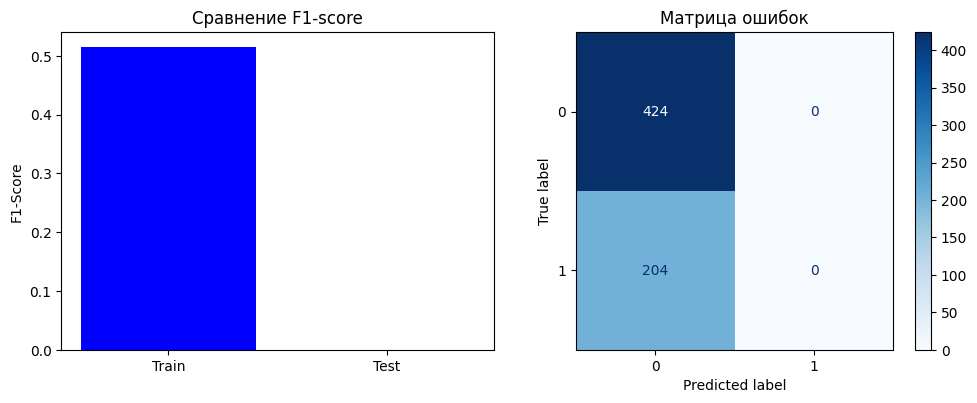

In [177]:
import matplotlib.pyplot as plt

# Простейшая визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# 1. F1-score
ax1.bar(['Train', 'Test'], [f1_train, f1_test], color=['blue', 'red'])
ax1.set_ylabel('F1-Score')
ax1.set_title('Сравнение F1-score')

# 2. Матрица ошибок
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, 
                                        ax=ax2, cmap='Blues')
ax2.set_title('Матрица ошибок')

plt.tight_layout()
plt.show()



ПРОСТАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


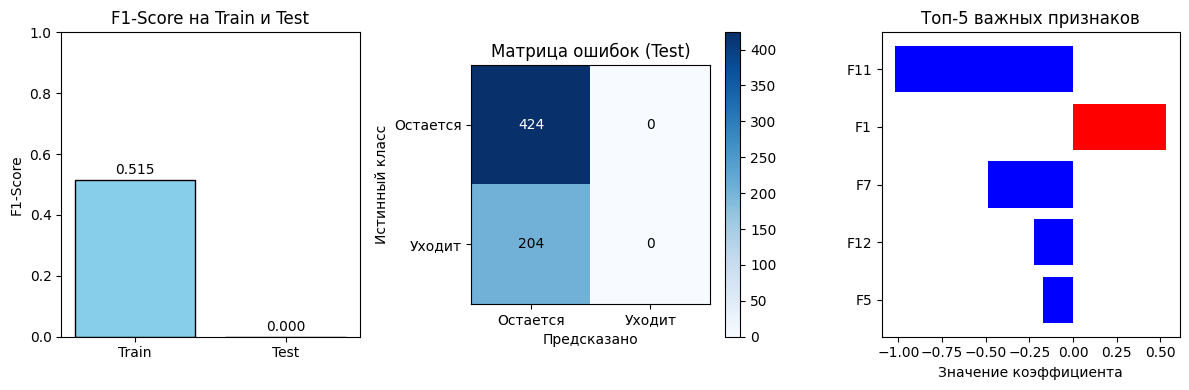


📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
------------------------------
F1-score на трейне: 0.5145
F1-score на тесте:  0.0000
Разница:            0.5145

🔍 МАТРИЦА ОШИБОК (Test):
True Negative:  424 (правильно 'остается')
False Positive: 0 (ошибка: сказали 'уйдет', но остался)
False Negative: 204 (ошибка: сказали 'остается', но ушел)
True Positive:  0 (правильно 'уходит')

✅ Accuracy: 67.52%

⚠️  Внимание: возможное переобучение!
   (большая разница между train и test)


In [178]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

print("=" * 50)
print("ПРОСТАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 50)

# 1. Создаем фигуру
plt.figure(figsize=(12, 4))

# 2. График 1: Сравнение F1-score
plt.subplot(1, 3, 1)
labels = ['Train', 'Test']
scores = [f1_train, f1_test]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(labels, scores, color=colors, edgecolor='black')
plt.ylabel('F1-Score')
plt.title('F1-Score на Train и Test')
plt.ylim(0, 1)

# Добавляем значения на столбцы
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# 3. График 2: Матрица ошибок для теста
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_pred_test)
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Матрица ошибок (Test)')
plt.colorbar()

# Добавляем числа
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), 
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xticks([0, 1], ['Остается', 'Уходит'])
plt.yticks([0, 1], ['Остается', 'Уходит'])
plt.xlabel('Предсказано')
plt.ylabel('Истинный класс')

# 4. График 3: Важные признаки (коэффициенты модели)
plt.subplot(1, 3, 3)
coefficients = model.coef_[0]
features = [f'F{i+1}' for i in range(len(coefficients))]

# Берем топ-5 признаков
top_idx = np.argsort(np.abs(coefficients))[-5:]
top_coef = coefficients[top_idx]
top_features = [features[i] for i in top_idx]

colors_bar = ['red' if c > 0 else 'blue' for c in top_coef]
plt.barh(range(len(top_coef)), top_coef, color=colors_bar)
plt.yticks(range(len(top_coef)), top_features)
plt.xlabel('Значение коэффициента')
plt.title('Топ-5 важных признаков')

plt.tight_layout()
plt.show()

# 5. Простой текстовый вывод
print(f"\n📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:")
print("-" * 30)
print(f"F1-score на трейне: {f1_train:.4f}")
print(f"F1-score на тесте:  {f1_test:.4f}")
print(f"Разница:            {abs(f1_train - f1_test):.4f}")

print(f"\n🔍 МАТРИЦА ОШИБОК (Test):")
print(f"True Negative:  {cm[0,0]} (правильно 'остается')")
print(f"False Positive: {cm[0,1]} (ошибка: сказали 'уйдет', но остался)")
print(f"False Negative: {cm[1,0]} (ошибка: сказали 'остается', но ушел)")
print(f"True Positive:  {cm[1,1]} (правильно 'уходит')")

print(f"\n✅ Accuracy: {(cm[0,0] + cm[1,1]) / cm.sum():.2%}")

# Проверка на переобучение
if f1_train - f1_test > 0.15:
    print(f"\n⚠️  Внимание: возможное переобучение!")
    print(f"   (большая разница между train и test)")
elif f1_test > 0.6:
    print(f"\n🎉 Хорошая модель!")
else:
    print(f"\n📉 Модель нуждается в улучшении")

### Задание 5.4 (2 балла)

Обучите модель логистической регрессии (`Logistic Regression`) на тренировочных данных. Позаботьтесь о воспроизводимости результата, установив конкретное значение параметра `random_state` (например, число 42).

Сделайте предсказание меток классов для тренировочной и тестовой выборок. 

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках. 

Проинтерпретируйте полученные результаты, ответив на следующий вопрос:
* Как вы считаете, является ли ваша модель переобученной или недообученной?

> **Примечание.** Будем считать, что модель нас не удовлетворяет (считается недообученной), если значение целевой метрики на тестовой выборке меньше 0.5.

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * построена модель логистической регрессии, решающая поставленную задачу;
    * с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится ответ на поставленный в задании вопрос.

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [179]:
#Создаём объект класса LogisticRegression
model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    penalty='l2', 
    class_weight='balanced', # L1-регуляризация
    C=0.3,                # слабая регуляризация
    solver='liblinear'     # ⭐ ПОДДЕРЖИВАЕТ L1! (или 'saga')
)
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)  # ← предсказания на ТЕСТОВЫХ данных
f1_test = f1_score(y_test, y_pred_test)  # ← y_test = ТЕСТОВЫЕ метки


y_pred_train = model.predict(X_train_scaled)  # ← предсказания на ТРЕНИРОВОЧНЫХ данных
f1_train = f1_score(y_train, y_pred_train)  # ← y_train = ТРЕНИРОВОЧНЫХ метки
print(f"F1-score на трейне: {f1_train:.4f}")
print(f"F1-score на тесте:  {f1_test:.4f}")
print(f"Разница:            {abs(f1_train - f1_test):.4f}")

print("\nПодробный отчет по тренеровочным данным:")
print(classification_report(y_train, y_pred_train, 
                           target_names=['Остается (0)', 'Уходит (1)']))
print("\nПодробный отчет по тестовым данным:")
print(classification_report(y_test, y_pred_test, 
                           target_names=['Остается (0)', 'Уходит (1)']))

F1-score на трейне: 0.5981
F1-score на тесте:  0.2531
Разница:            0.3450

Подробный отчет по тренеровочным данным:
              precision    recall  f1-score   support

Остается (0)       0.83      0.68      0.75      1271
  Уходит (1)       0.52      0.71      0.60       610

    accuracy                           0.69      1881
   macro avg       0.67      0.70      0.67      1881
weighted avg       0.73      0.69      0.70      1881


Подробный отчет по тестовым данным:
              precision    recall  f1-score   support

Остается (0)       0.71      0.98      0.82       424
  Уходит (1)       0.76      0.15      0.25       204

    accuracy                           0.71       628
   macro avg       0.73      0.56      0.54       628
weighted avg       0.72      0.71      0.64       628



ПРОСТАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


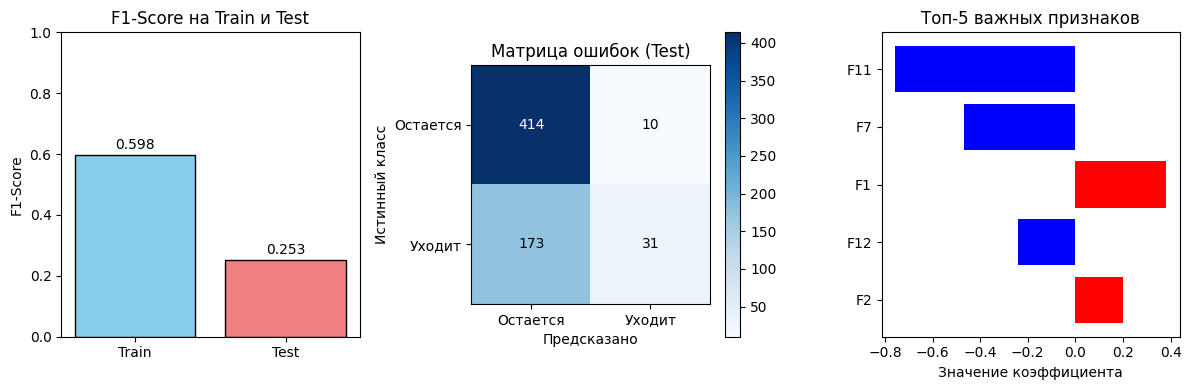


📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
------------------------------
F1-score на трейне: 0.5981
F1-score на тесте:  0.2531
Разница:            0.3450

🔍 МАТРИЦА ОШИБОК (Test):
True Negative:  414 (правильно 'остается')
False Positive: 10 (ошибка: сказали 'уйдет', но остался)
False Negative: 173 (ошибка: сказали 'остается', но ушел)
True Positive:  31 (правильно 'уходит')

✅ Accuracy: 70.86%

⚠️  Внимание: возможное переобучение!
   (большая разница между train и test)


In [180]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

print("=" * 50)
print("ПРОСТАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 50)

# 1. Создаем фигуру
plt.figure(figsize=(12, 4))

# 2. График 1: Сравнение F1-score
plt.subplot(1, 3, 1)
labels = ['Train', 'Test']
scores = [f1_train, f1_test]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(labels, scores, color=colors, edgecolor='black')
plt.ylabel('F1-Score')
plt.title('F1-Score на Train и Test')
plt.ylim(0, 1)

# Добавляем значения на столбцы
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# 3. График 2: Матрица ошибок для теста
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_pred_test)
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Матрица ошибок (Test)')
plt.colorbar()

# Добавляем числа
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), 
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xticks([0, 1], ['Остается', 'Уходит'])
plt.yticks([0, 1], ['Остается', 'Уходит'])
plt.xlabel('Предсказано')
plt.ylabel('Истинный класс')

# 4. График 3: Важные признаки (коэффициенты модели)
plt.subplot(1, 3, 3)
coefficients = model.coef_[0]
features = [f'F{i+1}' for i in range(len(coefficients))]

# Берем топ-5 признаков
top_idx = np.argsort(np.abs(coefficients))[-5:]
top_coef = coefficients[top_idx]
top_features = [features[i] for i in top_idx]

colors_bar = ['red' if c > 0 else 'blue' for c in top_coef]
plt.barh(range(len(top_coef)), top_coef, color=colors_bar)
plt.yticks(range(len(top_coef)), top_features)
plt.xlabel('Значение коэффициента')
plt.title('Топ-5 важных признаков')

plt.tight_layout()
plt.show()

# 5. Простой текстовый вывод
print(f"\n📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:")
print("-" * 30)
print(f"F1-score на трейне: {f1_train:.4f}")
print(f"F1-score на тесте:  {f1_test:.4f}")
print(f"Разница:            {abs(f1_train - f1_test):.4f}")

print(f"\n🔍 МАТРИЦА ОШИБОК (Test):")
print(f"True Negative:  {cm[0,0]} (правильно 'остается')")
print(f"False Positive: {cm[0,1]} (ошибка: сказали 'уйдет', но остался)")
print(f"False Negative: {cm[1,0]} (ошибка: сказали 'остается', но ушел)")
print(f"True Positive:  {cm[1,1]} (правильно 'уходит')")

print(f"\n✅ Accuracy: {(cm[0,0] + cm[1,1]) / cm.sum():.2%}")

# Проверка на переобучение
if f1_train - f1_test > 0.15:
    print(f"\n⚠️  Внимание: возможное переобучение!")
    print(f"   (большая разница между train и test)")
elif f1_test > 0.6:
    print(f"\n🎉 Хорошая модель!")
else:
    print(f"\n📉 Модель нуждается в улучшении")

F1-score на тесте: 0.5649
ПРОСТАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


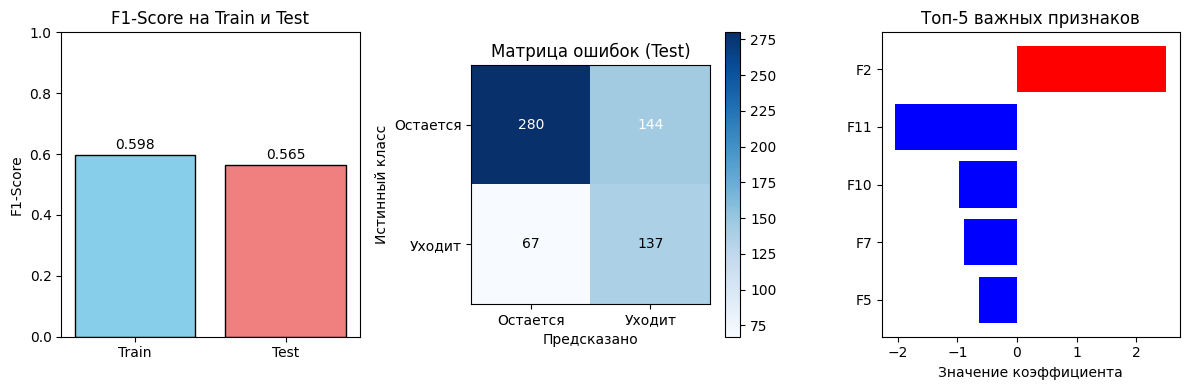


📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
------------------------------
F1-score на трейне: 0.5981
F1-score на тесте:  0.5649
Разница:            0.0331

🔍 МАТРИЦА ОШИБОК (Test):
True Negative:  280 (правильно 'остается')
False Positive: 144 (ошибка: сказали 'уйдет', но остался)
False Negative: 67 (ошибка: сказали 'остается', но ушел)
True Positive:  137 (правильно 'уходит')

✅ Accuracy: 66.40%

📉 Модель нуждается в улучшении


In [181]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# 1. Масштабирование (ОДИН РАЗ!)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)  # обучаем на train
X_test_scaled = scaler.transform(X_test)        # применяем к test

# 2. Обучение
model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    penalty='l2', 
    class_weight='balanced', # L1-регуляризация
    C=0.3,                # слабая регуляризация
    solver='liblinear'     # ⭐ ПОДДЕРЖИВАЕТ L1! (или 'saga')
)
model.fit(X_train_scaled, y_train)

# 3. Предсказания на ТЕСТЕ
y_pred_test = model.predict(X_test_scaled)  # ← на тесте!

# 4. Оценка на ТЕСТЕ
f1_test = f1_score(y_test, y_pred_test)     # ← с тестовыми метками

print(f"F1-score на тесте: {f1_test:.4f}")

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

print("=" * 50)
print("ПРОСТАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 50)

# 1. Создаем фигуру
plt.figure(figsize=(12, 4))

# 2. График 1: Сравнение F1-score
plt.subplot(1, 3, 1)
labels = ['Train', 'Test']
scores = [f1_train, f1_test]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(labels, scores, color=colors, edgecolor='black')
plt.ylabel('F1-Score')
plt.title('F1-Score на Train и Test')
plt.ylim(0, 1)

# Добавляем значения на столбцы
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# 3. График 2: Матрица ошибок для теста
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_pred_test)
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Матрица ошибок (Test)')
plt.colorbar()

# Добавляем числа
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), 
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xticks([0, 1], ['Остается', 'Уходит'])
plt.yticks([0, 1], ['Остается', 'Уходит'])
plt.xlabel('Предсказано')
plt.ylabel('Истинный класс')

# 4. График 3: Важные признаки (коэффициенты модели)
plt.subplot(1, 3, 3)
coefficients = model.coef_[0]
features = [f'F{i+1}' for i in range(len(coefficients))]

# Берем топ-5 признаков
top_idx = np.argsort(np.abs(coefficients))[-5:]
top_coef = coefficients[top_idx]
top_features = [features[i] for i in top_idx]

colors_bar = ['red' if c > 0 else 'blue' for c in top_coef]
plt.barh(range(len(top_coef)), top_coef, color=colors_bar)
plt.yticks(range(len(top_coef)), top_features)
plt.xlabel('Значение коэффициента')
plt.title('Топ-5 важных признаков')

plt.tight_layout()
plt.show()

# 5. Простой текстовый вывод
print(f"\n📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:")
print("-" * 30)
print(f"F1-score на трейне: {f1_train:.4f}")
print(f"F1-score на тесте:  {f1_test:.4f}")
print(f"Разница:            {abs(f1_train - f1_test):.4f}")

print(f"\n🔍 МАТРИЦА ОШИБОК (Test):")
print(f"True Negative:  {cm[0,0]} (правильно 'остается')")
print(f"False Positive: {cm[0,1]} (ошибка: сказали 'уйдет', но остался)")
print(f"False Negative: {cm[1,0]} (ошибка: сказали 'остается', но ушел)")
print(f"True Positive:  {cm[1,1]} (правильно 'уходит')")

print(f"\n✅ Accuracy: {(cm[0,0] + cm[1,1]) / cm.sum():.2%}")

# Проверка на переобучение
if f1_train - f1_test > 0.15:
    print(f"\n⚠️  Внимание: возможное переобучение!")
    print(f"   (большая разница между train и test)")
elif f1_test > 0.6:
    print(f"\n🎉 Хорошая модель!")
else:
    print(f"\n📉 Модель нуждается в улучшении")

Реализованная мной метрика, и релизованная метрика ИИ имеет существенную разницу. из первой метрики видно что зависимость начинающаяся от F1-score на тесте:  0.2554 что является плохим результатом. ИИ - в F1-score на тесте:  0.5744. что является хорошим результатом и считается применяемым

### Задание 5.5 (2 балла)

Сгенерируйте полиномиальные признаки третьей степени для тренировочной и тестовой выборок. Используйте класс `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` выставите в значение `False`.

> **Примечание.** Обратите внимание, что для генерации полиномов необходимо использовать масштабированные данные.

Обучите модель логистической регрессии на полиномиальных признаках (`Logistic Regression`). Позаботьтесь о воспроизводимости результат, установив конкретное значение параметра `random_state` (например, число 42).

Предскажите метки классов для тренировочной и тестовой выборок.

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках для модели, обученной на полиномиальных признаках.

Сравните результат с полученным ранее. Удалось ли вам улучшить качество вашей модели?

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * сгенерированы полиномиальные признаки третьей степени;
    * построена модель логистической регрессии, решающая поставленную задачу на основе сгенерированных признаков;
    * с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [182]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 16)
Test shape: (628, 16)


In [183]:
from sklearn.preprocessing import PolynomialFeatures
# Для сравнения
scaler = StandardScaler()
poly = PolynomialFeatures( degree =3, include_bias=False)
i = False
#Маштабирование
# Применяем трансформацию к ТРЕНИРОВАЧНЫМ ПРИЗНАКАМ (X_train)
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform для train
if i == True:
	print("Обучаем StandardScaler на X_train_C...")
	print(f"   X_train_scaled shape: {X_train_scaled.shape}")
	print(f"   X_train_scaled range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")

# Применяем трансформацию к ТЕСТОВЫМ ПРИЗНАКАМ (X_test)
X_test_scaled = scaler.transform(X_test)  
if i == True:
	print("Применяем трансформацию к X_test_C...")
	print(f"   X_test_scaled shape: {X_test_scaled.shape}")
	print(f"   X_test_scaled range: [{X_test_scaled.min():.2f}, {X_test_scaled.max():.2f}]")
	print(f"X_test_scaled : {X_test_scaled}")

# Полинаминальные признаки
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
	random_state=42, class_weight= 'balanced', C = 0.1, max_iter=500
)
model.fit(X_train_poly, y_train)
y_pred_test = model.predict(X_test_poly)

f1_test = f1_score(y_test, y_pred_test)
if i == False:
	print(f"F1-score на трейне: {f1_train:.4f}")
	print(f"F1-score на тесте:  {f1_test:.4f}")
	print(f"Разница:            {abs(f1_train - f1_test):.4f}")

	print("\nПодробный отчет по тренеровочным данным:")
	print(classification_report(y_train, y_pred_train, 
										target_names=['Остается (0)', 'Уходит (1)']))
	print("\nПодробный отчет по тестовым данным:")
	print(classification_report(y_test, y_pred_test, 
										target_names=['Остается (0)', 'Уходит (1)']))
# 0.6374133949191686
# F1-score на трейне: 0.5981
# F1-score на тесте:  0.5893
# Разница:            0.0087

# 0.1

# F1-score на трейне: 0.5981
# F1-score на тесте:  0.5893
# Разница:            0.0087

# 0.6374133949191686
# F1-score на трейне: 0.5981
# F1-score на тесте:  0.6374
# Разница:            0.0393


F1-score на трейне: 0.5981
F1-score на тесте:  0.6420
Разница:            0.0440

Подробный отчет по тренеровочным данным:
              precision    recall  f1-score   support

Остается (0)       0.83      0.68      0.75      1271
  Уходит (1)       0.52      0.71      0.60       610

    accuracy                           0.69      1881
   macro avg       0.67      0.70      0.67      1881
weighted avg       0.73      0.69      0.70      1881


Подробный отчет по тестовым данным:
              precision    recall  f1-score   support

Остается (0)       0.84      0.79      0.81       424
  Уходит (1)       0.61      0.68      0.64       204

    accuracy                           0.75       628
   macro avg       0.72      0.73      0.73       628
weighted avg       0.76      0.75      0.76       628



ПРОСТАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


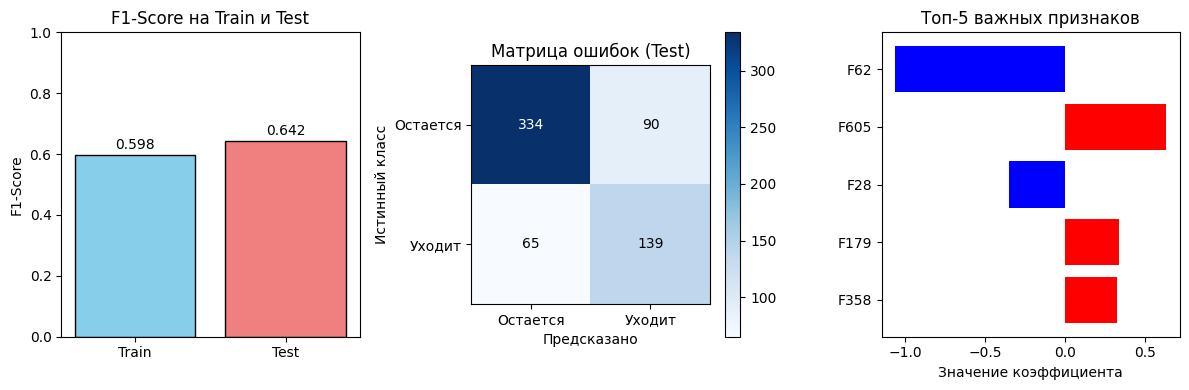


📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
------------------------------
F1-score на трейне: 0.5981
F1-score на тесте:  0.6420
Разница:            0.0440

🔍 МАТРИЦА ОШИБОК (Test):
True Negative:  334 (правильно 'остается')
False Positive: 90 (ошибка: сказали 'уйдет', но остался)
False Negative: 65 (ошибка: сказали 'остается', но ушел)
True Positive:  139 (правильно 'уходит')

✅ Accuracy: 75.32%

🎉 Хорошая модель!


In [184]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

print("=" * 50)
print("ПРОСТАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 50)

# 1. Создаем фигуру
plt.figure(figsize=(12, 4))

# 2. График 1: Сравнение F1-score
plt.subplot(1, 3, 1)
labels = ['Train', 'Test']
scores = [f1_train, f1_test]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(labels, scores, color=colors, edgecolor='black')
plt.ylabel('F1-Score')
plt.title('F1-Score на Train и Test')
plt.ylim(0, 1)

# Добавляем значения на столбцы
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# 3. График 2: Матрица ошибок для теста
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_pred_test)
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Матрица ошибок (Test)')
plt.colorbar()

# Добавляем числа
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), 
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xticks([0, 1], ['Остается', 'Уходит'])
plt.yticks([0, 1], ['Остается', 'Уходит'])
plt.xlabel('Предсказано')
plt.ylabel('Истинный класс')

# 4. График 3: Важные признаки (коэффициенты модели)
plt.subplot(1, 3, 3)
coefficients = model.coef_[0]
features = [f'F{i+1}' for i in range(len(coefficients))]

# Берем топ-5 признаков
top_idx = np.argsort(np.abs(coefficients))[-5:]
top_coef = coefficients[top_idx]
top_features = [features[i] for i in top_idx]

colors_bar = ['red' if c > 0 else 'blue' for c in top_coef]
plt.barh(range(len(top_coef)), top_coef, color=colors_bar)
plt.yticks(range(len(top_coef)), top_features)
plt.xlabel('Значение коэффициента')
plt.title('Топ-5 важных признаков')

plt.tight_layout()
plt.show()

# 5. Простой текстовый вывод
print(f"\n📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:")
print("-" * 30)
print(f"F1-score на трейне: {f1_train:.4f}")
print(f"F1-score на тесте:  {f1_test:.4f}")
print(f"Разница:            {abs(f1_train - f1_test):.4f}")

print(f"\n🔍 МАТРИЦА ОШИБОК (Test):")
print(f"True Negative:  {cm[0,0]} (правильно 'остается')")
print(f"False Positive: {cm[0,1]} (ошибка: сказали 'уйдет', но остался)")
print(f"False Negative: {cm[1,0]} (ошибка: сказали 'остается', но ушел)")
print(f"True Positive:  {cm[1,1]} (правильно 'уходит')")

print(f"\n✅ Accuracy: {(cm[0,0] + cm[1,1]) / cm.sum():.2%}")

# Проверка на переобучение
if f1_train - f1_test > 0.15:
    print(f"\n⚠️  Внимание: возможное переобучение!")
    print(f"   (большая разница между train и test)")
elif f1_test > 0.6:
    print(f"\n🎉 Хорошая модель!")
else:
    print(f"\n📉 Модель нуждается в улучшении")

Модель стала лучше, в виду расширения области видимости логической регрессии за счет внедрения полиноминального распределения данных 

### Задание 5.6. (2 балла)


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. В качестве модели используйте логистическую регрессию, обученную на полиномиальных признаках. 

В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список.

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните результат с полученными ранее.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для построения графика зависимости значения выбранной метрики от порога вероятности;
    * найден оптимальный порог вероятности, на котором достигается наибольшее значение выбранной метрики на тестовой выборке;
    * на основе найденного порога вероятности построено предсказание модели для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

Оптимальный порог: 0.50
Лучший F1-score: 0.6420

Все значения F1-score:
Порог 0.10: F1 = 0.5879
Порог 0.15: F1 = 0.6054
Порог 0.20: F1 = 0.6073
Порог 0.25: F1 = 0.5929
Порог 0.30: F1 = 0.6062
Порог 0.35: F1 = 0.6122
Порог 0.40: F1 = 0.6186
Порог 0.45: F1 = 0.6198
Порог 0.50: F1 = 0.6420
Порог 0.55: F1 = 0.6220
Порог 0.60: F1 = 0.6284
Порог 0.65: F1 = 0.6073
Порог 0.70: F1 = 0.5870
Порог 0.75: F1 = 0.5690
Порог 0.80: F1 = 0.5433
Порог 0.85: F1 = 0.5094
Порог 0.90: F1 = 0.4521
Порог 0.95: F1 = 0.4000


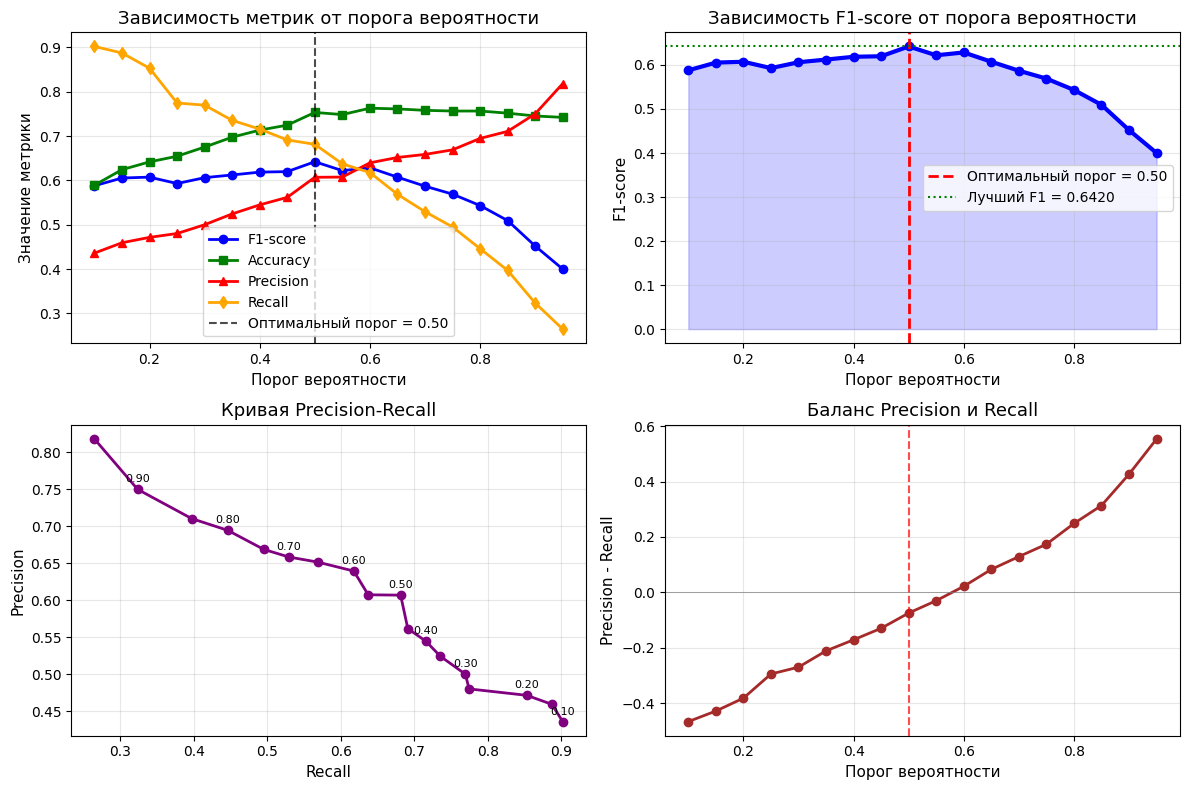


Топ-5 лучших порогов по F1-score:
1. Порог 0.50: F1=0.6420, Accuracy=0.7532, Precision=0.6070, Recall=0.6814
2. Порог 0.60: F1=0.6284, Accuracy=0.7627, Precision=0.6396, Recall=0.6176
3. Порог 0.55: F1=0.6220, Accuracy=0.7484, Precision=0.6075, Recall=0.6373
4. Порог 0.45: F1=0.6198, Accuracy=0.7245, Precision=0.5618, Recall=0.6912
5. Порог 0.40: F1=0.6186, Accuracy=0.7134, Precision=0.5448, Recall=0.7157

Используем оптимальный порог 0.50:

Сравнение с порогом по умолчанию (0.5):
------------------------------------------------------------
Метрика      Порог 0.5    Оптимальный  Изменение   
------------------------------------------------------------
F1           0.6420       0.6420       0.0000      
Accuracy     0.7532       0.7532       0.0000      
Precision    0.6070       0.6070       0.0000      
Recall       0.6814       0.6814       0.0000      


In [185]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])

# Инициализируем список, куда будем сохранять метрики
scores_f1 = []
scores_accuracy = []
scores_precision = []
scores_recall = []

# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)

# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрики
    f1 = f1_score(y_test, y_test_pred_poly)
    accuracy = accuracy_score(y_test, y_test_pred_poly)
    precision = precision_score(y_test, y_test_pred_poly)
    recall = recall_score(y_test, y_test_pred_poly)
    
    # Добавляем результаты в списки
    scores_f1.append(f1)
    scores_accuracy.append(accuracy)
    scores_precision.append(precision)
    scores_recall.append(recall)

# Находим оптимальный порог для F1-score
best_threshold_idx = np.argmax(scores_f1)
best_threshold = thresholds[best_threshold_idx]
best_f1 = scores_f1[best_threshold_idx]

print(f'Оптимальный порог: {best_threshold:.2f}')
print(f'Лучший F1-score: {best_f1:.4f}')
print(f'\nВсе значения F1-score:')
for i, (th, f1_val) in enumerate(zip(thresholds, scores_f1)):
    print(f'Порог {th:.2f}: F1 = {f1_val:.4f}')

# Создаем график с несколькими метриками
plt.figure(figsize=(12, 8))

# График 1: Все метрики на одном графике
plt.subplot(2, 2, 1)
plt.plot(thresholds, scores_f1, marker='o', label='F1-score', linewidth=2, color='blue')
plt.plot(thresholds, scores_accuracy, marker='s', label='Accuracy', linewidth=2, color='green')
plt.plot(thresholds, scores_precision, marker='^', label='Precision', linewidth=2, color='red')
plt.plot(thresholds, scores_recall, marker='d', label='Recall', linewidth=2, color='orange')
plt.axvline(x=best_threshold, color='black', linestyle='--', alpha=0.7, label=f'Оптимальный порог = {best_threshold:.2f}')
plt.xlabel('Порог вероятности', fontsize=11)
plt.ylabel('Значение метрики', fontsize=11)
plt.title('Зависимость метрик от порога вероятности', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Только F1-score с детализацией
plt.subplot(2, 2, 2)
plt.plot(thresholds, scores_f1, marker='o', linewidth=3, color='blue')
plt.fill_between(thresholds, scores_f1, alpha=0.2, color='blue')
plt.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, label=f'Оптимальный порог = {best_threshold:.2f}')
plt.axhline(y=best_f1, color='green', linestyle=':', linewidth=1.5, label=f'Лучший F1 = {best_f1:.4f}')
plt.xlabel('Порог вероятности', fontsize=11)
plt.ylabel('F1-score', fontsize=11)
plt.title('Зависимость F1-score от порога вероятности', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Precision vs Recall
plt.subplot(2, 2, 3)
plt.plot(scores_recall, scores_precision, marker='o', linewidth=2, color='purple')
for i, th in enumerate(thresholds):
    if i % 2 == 0:  # подпишем только каждый второй порог для читаемости
        plt.annotate(f'{th:.2f}', (scores_recall[i], scores_precision[i]), 
                    textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Кривая Precision-Recall', fontsize=13)
plt.grid(True, alpha=0.3)

# График 4: Разница между метриками
plt.subplot(2, 2, 4)
diff_precision_recall = [p - r for p, r in zip(scores_precision, scores_recall)]
plt.plot(thresholds, diff_precision_recall, marker='o', linewidth=2, color='brown')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Порог вероятности', fontsize=11)
plt.ylabel('Precision - Recall', fontsize=11)
plt.title('Баланс Precision и Recall', fontsize=13)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Таблица с результатами для лучших порогов
print("\nТоп-5 лучших порогов по F1-score:")
results = []
for i in range(len(thresholds)):
    results.append({
        'Порог': thresholds[i],
        'F1': scores_f1[i],
        'Accuracy': scores_accuracy[i],
        'Precision': scores_precision[i],
        'Recall': scores_recall[i]
    })

# Сортируем по F1-score
results_sorted = sorted(results, key=lambda x: x['F1'], reverse=True)

for i in range(min(5, len(results_sorted))):
    r = results_sorted[i]
    print(f"{i+1}. Порог {r['Порог']:.2f}: F1={r['F1']:.4f}, "
          f"Accuracy={r['Accuracy']:.4f}, Precision={r['Precision']:.4f}, Recall={r['Recall']:.4f}")

# Делаем предсказание с оптимальным порогом
print(f"\nИспользуем оптимальный порог {best_threshold:.2f}:")
y_test_pred_optimal = y_test_proba_pred.apply(lambda x: 1 if x > best_threshold else 0)

# Сравнение с порогом по умолчанию (0.5)
default_threshold = 0.5
y_test_pred_default = y_test_proba_pred.apply(lambda x: 1 if x > default_threshold else 0)

print(f"\nСравнение с порогом по умолчанию ({default_threshold}):")
print("-" * 60)
print(f"{'Метрика':<12} {'Порог 0.5':<12} {'Оптимальный':<12} {'Изменение':<12}")
print("-" * 60)

metrics = ['F1', 'Accuracy', 'Precision', 'Recall']
default_values = [
    f1_score(y_test, y_test_pred_default),
    accuracy_score(y_test, y_test_pred_default),
    precision_score(y_test, y_test_pred_default),
    recall_score(y_test, y_test_pred_default)
]
optimal_values = [
    f1_score(y_test, y_test_pred_optimal),
    accuracy_score(y_test, y_test_pred_optimal),
    precision_score(y_test, y_test_pred_optimal),
    recall_score(y_test, y_test_pred_optimal)
]

for metric, default, optimal in zip(metrics, default_values, optimal_values):
    change = optimal - default
    change_str = f"+{change:.4f}" if change > 0 else f"{change:.4f}"
    print(f"{metric:<12} {default:<12.4f} {optimal:<12.4f} {change_str:<12}")

## Практика: деревья решений и случайный лес

Мы продолжаем решать задачу прогнозирования оттока клиентов банка.

Ранее мы построили модель логистической регрессии, затем добавили в модель полиномиальные признаки и подобрали оптимальный порог вероятности для логистической регрессии.

> Теперь попробуем решить задачу с помощью деревьев решений и лесов.


> **Примечание №1.** Для выполнения дальнейших заданий необходимо совершить уже знакомые шаги предобработки с данными об оттоке клиентов банка, а именно:
* выделить данные, относящиеся к отделениям банка в Германии;
* избавиться от заведомо неинформативных признаков;
* расширить датасет путём добавления новых признаков;
* разделить выборку на тренировочную и тестовую со стратификацией.

> **Примечание №2.** Деревья решений — алгоритм, способный уловить нелинейные зависимости. Генерация полиномиальных признаков практически не имеет значения.
Также деревья решений не чувствительны к масштабу признаков. Масштабирование исходных данных не играет роли при построении деревьев решения.
Поэтому для решения задачи используйте обучающую (`X_train`, `y_train`) и тестовую (`X_test`, `y_test`) выборки без полиномиальных столбцов.


In [186]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 16)
Test shape: (628, 16)


Импортируем необходимые для выполнения практики модули:

In [187]:
from sklearn import tree
from sklearn import ensemble

Приступим! Выполните задания 8.1–8.4.

### Задание 8.1. (2 балла)

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с неограниченной максимальной глубиной дерева. В качестве критерия информативности используйте энтропию Шеннона, остальные параметры оставьте по умолчанию. 

Также позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42). 

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сделайте вывод, ответив на вопрос:
* Как вы считаете, является полученная модель переобученной или недообученной? Попробуйте дать обоснование, почему так происходит.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос, а также обоснование полученного результата.

- Задание выполнено верно, но не приведено обоснование полученного результата или обоснование является некорректным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [188]:
#Создаём объект класса DecisionTreeClassifier
dt_clf_2d = tree.DecisionTreeClassifier(
    criterion='entropy', 
    random_state=42
)
#Обучаем дерево решений по алгоритму CART
dt_clf_2d.fit(X_train, y_train)


,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


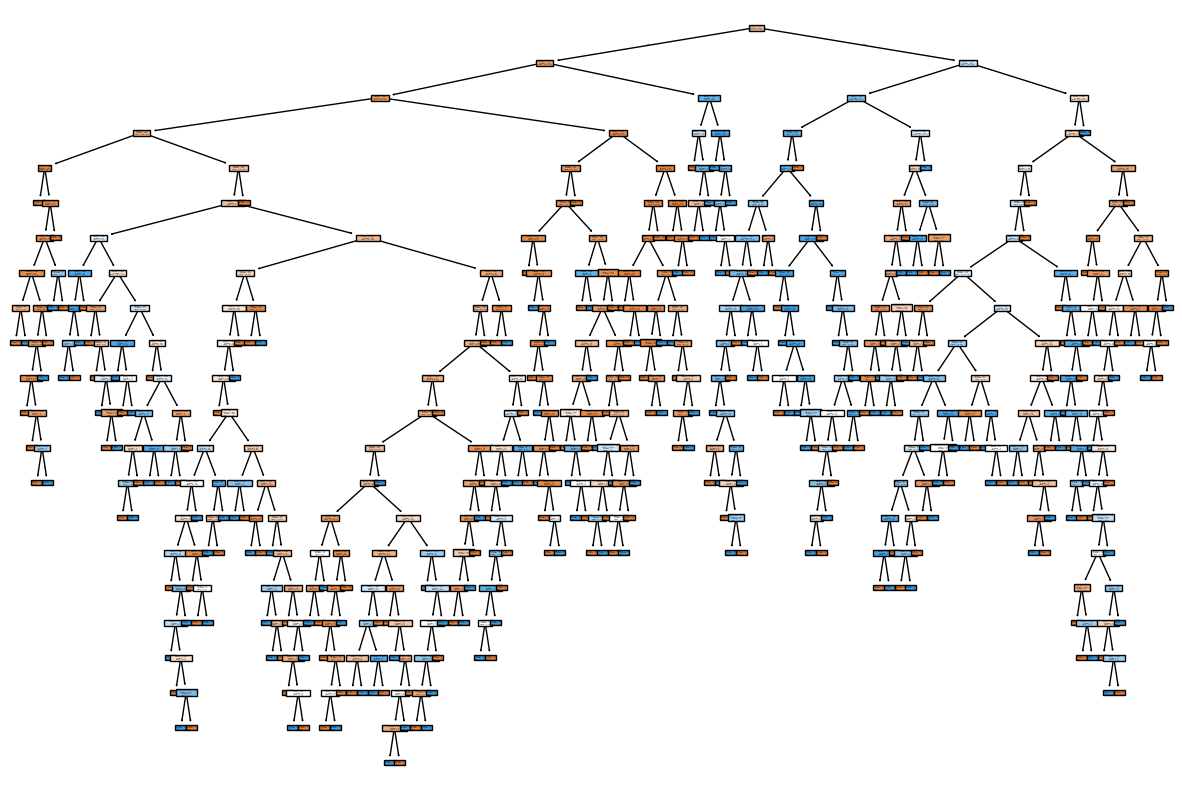

In [189]:
#Создаём фигуру для визуализации графа
fig = plt.figure(figsize=(15, 10))
#Строим граф дерева решений
tree_graph = tree.plot_tree(
    dt_clf_2d, #объект обученного дерева
    feature_names=X.columns, #названия факторов
    
    filled=True, #расцветка графа
);


In [190]:
# Предсказания на тестовой выборке
y_pred = dt_clf_2d.predict(X_test)

# Предсказания вероятностей (если нужно найти оптимальный порог)
y_pred_proba = dt_clf_2d.predict_proba(X_test)[:, 1]

In [191]:
# Оценка точности

f1 = f1_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred_proba)
recall = recall_score(y_test, y_pred_proba)
    
print(f'Accuracy:  {accuracy}')
print(f'F1:        {f1}')
print(f'Precision: {precision}')
print(f'Recall:    {recall}')

Accuracy:  0.7006369426751592
F1:        0.5369458128078818
Precision: 0.5396039603960396
Recall:    0.5343137254901961


In [192]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(f"TN: {cm[0,0]} | FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}  | TP: {cm[1,1]}")

# Расчёт на её основе
TN, FP, FN, TP = cm.ravel()
print(f"\nИстинно отрицательных: {TN}")
print(f"Ложноположительных: {FP}")
print(f"Ложноотрицательных: {FN}")
print(f"Истинноположительных: {TP}")

Матрица ошибок:
TN: 331 | FP: 93
FN: 95  | TP: 109

Истинно отрицательных: 331
Ложноположительных: 93
Ложноотрицательных: 95
Истинноположительных: 109


Программа ошибается в 30% случаев что меньше чем в прошлые разы, но не идеально 

### Задание 8.2. (1 балл)

Давайте «подстрижём» наше дерево. 

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с максимальной глубиной 8. В качестве критерия информативности используйте энтропию Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните результат с полученными ранее. Сделайте вывод.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балла**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [ ]:
#Создаём объект класса DecisionTreeClassifier
dt_clf_2d_0 = tree.DecisionTreeClassifier(
    criterion='entropy', max_depth = 8, min_samples_leaf = 10
    random_state=42
)
#Обучаем дерево решений по алгоритму CART
dt_clf_2d_0.fit(X_train, y_train)


,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


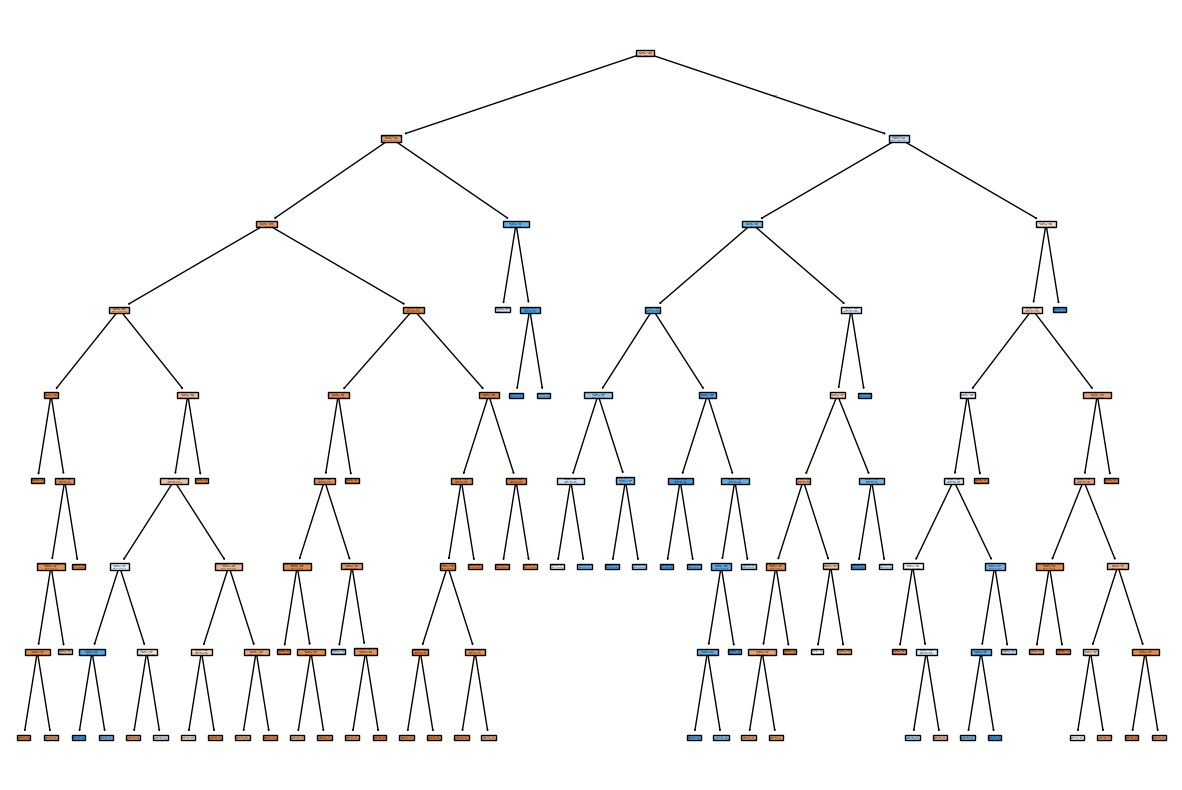

In [194]:
#Создаём фигуру для визуализации графа
fig = plt.figure(figsize=(15, 10))
#Строим граф дерева решений
tree_graph = tree.plot_tree(
    dt_clf_2d_0, #объект обученного дерева
    feature_names=X.columns, #названия факторов
    
    filled=True, #расцветка графа
);

In [195]:
# 1. Получаем бинарные предсказания (0 или 1)
y_pred = dt_clf_2d_0.predict(X_test)

# 2. Получаем вероятности (для ROC-кривой или подбора порога)
y_pred_proba_0 = dt_clf_2d_0.predict_proba(X_test)[:, 1]

# 3. Считаем метрики с БИНАРНЫМИ предсказаниями
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'F1:        {f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(f"TN: {cm[0,0]} | FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}  | TP: {cm[1,1]}")
# Расчёт на её основе
TN, FP, FN, TP = cm.ravel()
print(f"\nИстинно отрицательных: {TN}")
print(f"Ложноположительных: {FP}")
print(f"Ложноотрицательных: {FN}")
print(f"Истинноположительных: {TP}")

Accuracy:  0.7866
F1:        0.6398
Precision: 0.7083
Recall:    0.5833
Матрица ошибок:
TN: 375 | FP: 49
FN: 85  | TP: 119

Истинно отрицательных: 375
Ложноположительных: 49
Ложноотрицательных: 85
Истинноположительных: 119


Правильность поднялась до 78, уменьшилось Ложноположительных и Ложноотрицательных результатов, что является плюсом 

### Задание 8.3. (1 балл)

Давайте воспользуемся случайным лесом. 

Постройте случайный лес (`RandomForestClassifier`) из 500 деревьев с максимальной глубиной 8. Критерий информативности — энтропия Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните качество одного дерева решений с качеством случайного леса на тестовой выборке. Смогли ли вы улучшить метрику?


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [209]:
#Создаём объект класса случайный лес
dt_clf_2d_0 = ensemble.RandomForestClassifier(
    n_estimators=500, #число деревьев
    criterion='entropy', #критерий эффективности
    max_depth=8, #максимальная глубина дерева
    min_samples_leaf = 10,
    max_features='sqrt', #число признаков из метода случайных подространств
    random_state=42 #генератор случайных чисел
)
#Обучаем модель 
dt_clf_2d_0.fit(X_train, y_train)

#Делаем предсказание класса
y_pred = dt_clf_2d_0.predict(X_test)
y_pred_proba = dt_clf_2d_0.predict_proba(X_test)[:, 1]

# 3. Применяем нужный порог (например, 0.55)
optimal_threshold = 0.55
y_pred_custom = (y_pred_proba > optimal_threshold).astype(int)
#Выводим отчёт о метриках
f1_1 = f1_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'F1:        {f1:.4f}')
print(f'f1_1:        {f1_1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(f"TN: {cm[0,0]} | FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}  | TP: {cm[1,1]}")
# Расчёт на её основе
TN, FP, FN, TP = cm.ravel()
print(f"\nИстинно отрицательных: {TN}")
print(f"Ложноположительных: {FP}")
print(f"Ложноотрицательных: {FN}")
print(f"Истинноположительных: {TP}")

Accuracy:  0.7930
F1:        0.6409
f1_1:        0.6108
Precision: 0.7342
Recall:    0.5686
Матрица ошибок:
TN: 382 | FP: 42
FN: 88  | TP: 116

Истинно отрицательных: 382
Ложноположительных: 42
Ложноотрицательных: 88
Истинноположительных: 116


> Ваши выводы и рассуждения — *здесь*

### Задание 8.4. (2 балла)

Мы на финишной прямой. 


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. **Используйте ту модель (из рассмотренных ранее), которая показала наилучшее качество на тестовой выборке.**


В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список. 

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните полученный результат с полученными ранее. 

Напишите небольшой вывод о проделанной работе, указав в нём, какая из рассмотренных нами моделей показала наилучший результат.

> **Примечание.** Помните о том, что в реальных задачах (а мы решали задачу на реальных данных) мы практически никогда не сможем получить значения метрик, близкие к 1. Если в задаче прогнозирования оттока ваша метрика превышает хотя бы значения 0.6-0.7, вашу модель уже можно считать хорошей и можно говорить о том, что она успешно справляется с задачей.

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Оптимальный порог: 0.35
Лучший F1-score: 0.6901

Все значения F1-score:
Порог 0.10: F1 = 0.5307
Порог 0.15: F1 = 0.5761
Порог 0.20: F1 = 0.6144
Порог 0.25: F1 = 0.6442
Порог 0.30: F1 = 0.6708
Порог 0.35: F1 = 0.6901
Порог 0.40: F1 = 0.6809
Порог 0.45: F1 = 0.6684
Порог 0.50: F1 = 0.6409
Порог 0.55: F1 = 0.6108
Порог 0.60: F1 = 0.5395
Порог 0.65: F1 = 0.4876
Порог 0.70: F1 = 0.4015
Порог 0.75: F1 = 0.3089
Порог 0.80: F1 = 0.2000
Порог 0.85: F1 = 0.0664
Порог 0.90: F1 = 0.0000
Порог 0.95: F1 = 0.0000


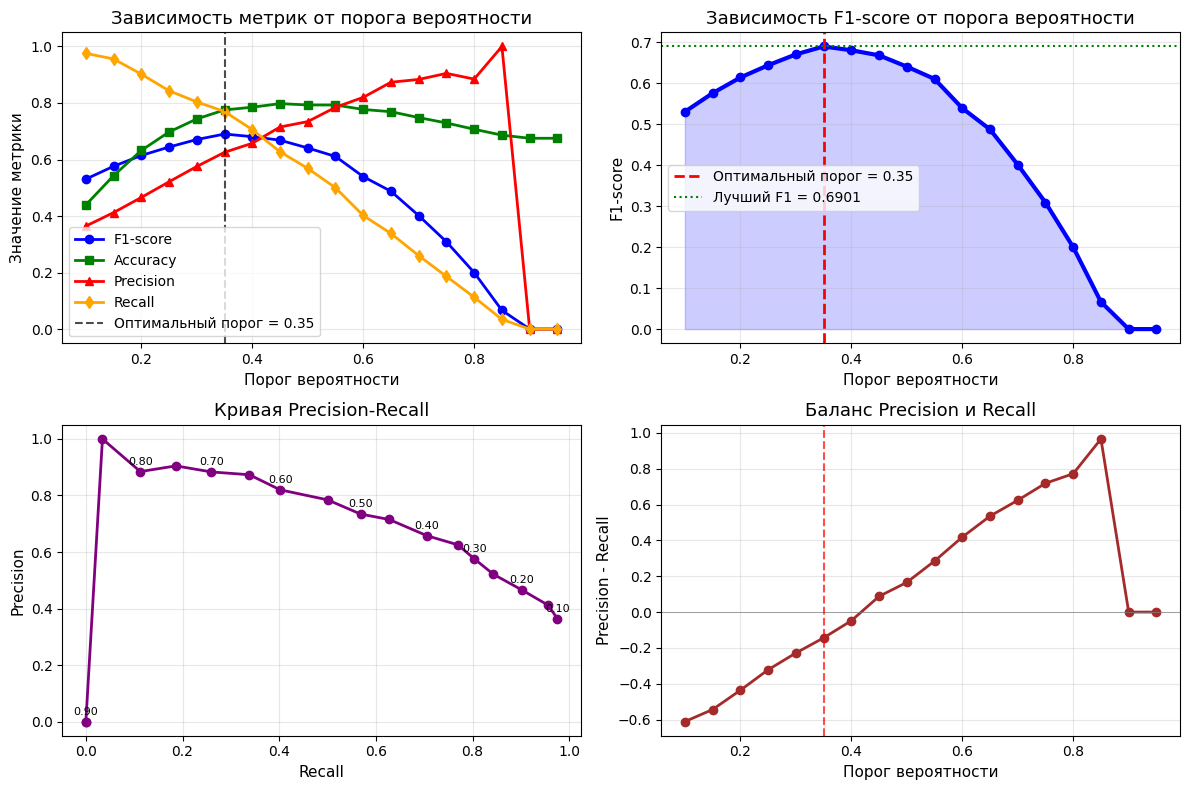


Топ-5 лучших порогов по F1-score:
1. Порог 0.35: F1=0.6901, Accuracy=0.7755, Precision=0.6255, Recall=0.7696
2. Порог 0.40: F1=0.6809, Accuracy=0.7850, Precision=0.6575, Recall=0.7059
3. Порог 0.30: F1=0.6708, Accuracy=0.7436, Precision=0.5754, Recall=0.8039
4. Порог 0.45: F1=0.6684, Accuracy=0.7978, Precision=0.7151, Recall=0.6275
5. Порог 0.25: F1=0.6442, Accuracy=0.6975, Precision=0.5212, Recall=0.8431

Используем оптимальный порог 0.35:

Сравнение с порогом по умолчанию (0.5):
------------------------------------------------------------
Метрика      Порог 0.5    Оптимальный  Изменение   
------------------------------------------------------------
F1           0.6409       0.6901       +0.0492     
Accuracy     0.7930       0.7755       -0.0175     
Precision    0.7342       0.6255       -0.1087     
Recall       0.5686       0.7696       +0.2010     


In [205]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(dt_clf_2d_0.predict_proba(X_test)[:, 1])

# Инициализируем список, куда будем сохранять метрики
scores_f1 = []
scores_accuracy = []
scores_precision = []
scores_recall = []

# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)

# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрики
    f1 = f1_score(y_test, y_test_pred_poly)
    accuracy = accuracy_score(y_test, y_test_pred_poly)
    precision = precision_score(y_test, y_test_pred_poly)
    recall = recall_score(y_test, y_test_pred_poly)
    
    # Добавляем результаты в списки
    scores_f1.append(f1)
    scores_accuracy.append(accuracy)
    scores_precision.append(precision)
    scores_recall.append(recall)

# Находим оптимальный порог для F1-score
best_threshold_idx = np.argmax(scores_f1)
best_threshold = thresholds[best_threshold_idx]
best_f1 = scores_f1[best_threshold_idx]

print(f'Оптимальный порог: {best_threshold:.2f}')
print(f'Лучший F1-score: {best_f1:.4f}')
print(f'\nВсе значения F1-score:')
for i, (th, f1_val) in enumerate(zip(thresholds, scores_f1)):
    print(f'Порог {th:.2f}: F1 = {f1_val:.4f}')

# Создаем график с несколькими метриками
plt.figure(figsize=(12, 8))

# График 1: Все метрики на одном графике
plt.subplot(2, 2, 1)
plt.plot(thresholds, scores_f1, marker='o', label='F1-score', linewidth=2, color='blue')
plt.plot(thresholds, scores_accuracy, marker='s', label='Accuracy', linewidth=2, color='green')
plt.plot(thresholds, scores_precision, marker='^', label='Precision', linewidth=2, color='red')
plt.plot(thresholds, scores_recall, marker='d', label='Recall', linewidth=2, color='orange')
plt.axvline(x=best_threshold, color='black', linestyle='--', alpha=0.7, label=f'Оптимальный порог = {best_threshold:.2f}')
plt.xlabel('Порог вероятности', fontsize=11)
plt.ylabel('Значение метрики', fontsize=11)
plt.title('Зависимость метрик от порога вероятности', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Только F1-score с детализацией
plt.subplot(2, 2, 2)
plt.plot(thresholds, scores_f1, marker='o', linewidth=3, color='blue')
plt.fill_between(thresholds, scores_f1, alpha=0.2, color='blue')
plt.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, label=f'Оптимальный порог = {best_threshold:.2f}')
plt.axhline(y=best_f1, color='green', linestyle=':', linewidth=1.5, label=f'Лучший F1 = {best_f1:.4f}')
plt.xlabel('Порог вероятности', fontsize=11)
plt.ylabel('F1-score', fontsize=11)
plt.title('Зависимость F1-score от порога вероятности', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Precision vs Recall
plt.subplot(2, 2, 3)
plt.plot(scores_recall, scores_precision, marker='o', linewidth=2, color='purple')
for i, th in enumerate(thresholds):
    if i % 2 == 0:  # подпишем только каждый второй порог для читаемости
        plt.annotate(f'{th:.2f}', (scores_recall[i], scores_precision[i]), 
                    textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Кривая Precision-Recall', fontsize=13)
plt.grid(True, alpha=0.3)

# График 4: Разница между метриками
plt.subplot(2, 2, 4)
diff_precision_recall = [p - r for p, r in zip(scores_precision, scores_recall)]
plt.plot(thresholds, diff_precision_recall, marker='o', linewidth=2, color='brown')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Порог вероятности', fontsize=11)
plt.ylabel('Precision - Recall', fontsize=11)
plt.title('Баланс Precision и Recall', fontsize=13)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Таблица с результатами для лучших порогов
print("\nТоп-5 лучших порогов по F1-score:")
results = []
for i in range(len(thresholds)):
    results.append({
        'Порог': thresholds[i],
        'F1': scores_f1[i],
        'Accuracy': scores_accuracy[i],
        'Precision': scores_precision[i],
        'Recall': scores_recall[i]
    })

# Сортируем по F1-score
results_sorted = sorted(results, key=lambda x: x['F1'], reverse=True)

for i in range(min(5, len(results_sorted))):
    r = results_sorted[i]
    print(f"{i+1}. Порог {r['Порог']:.2f}: F1={r['F1']:.4f}, "
          f"Accuracy={r['Accuracy']:.4f}, Precision={r['Precision']:.4f}, Recall={r['Recall']:.4f}")

# Делаем предсказание с оптимальным порогом
print(f"\nИспользуем оптимальный порог {best_threshold:.2f}:")
y_test_pred_optimal = y_test_proba_pred.apply(lambda x: 1 if x > best_threshold else 0)

# Сравнение с порогом по умолчанию (0.5)
default_threshold = 0.5
y_test_pred_default = y_test_proba_pred.apply(lambda x: 1 if x > default_threshold else 0)

print(f"\nСравнение с порогом по умолчанию ({default_threshold}):")
print("-" * 60)
print(f"{'Метрика':<12} {'Порог 0.5':<12} {'Оптимальный':<12} {'Изменение':<12}")
print("-" * 60)

metrics = ['F1', 'Accuracy', 'Precision', 'Recall']
default_values = [
    f1_score(y_test, y_test_pred_default),
    accuracy_score(y_test, y_test_pred_default),
    precision_score(y_test, y_test_pred_default),
    recall_score(y_test, y_test_pred_default)
]
optimal_values = [
    f1_score(y_test, y_test_pred_optimal),
    accuracy_score(y_test, y_test_pred_optimal),
    precision_score(y_test, y_test_pred_optimal),
    recall_score(y_test, y_test_pred_optimal)
]

for metric, default, optimal in zip(metrics, default_values, optimal_values):
    change = optimal - default
    change_str = f"+{change:.4f}" if change > 0 else f"{change:.4f}"
    print(f"{metric:<12} {default:<12.4f} {optimal:<12.4f} {change_str:<12}")

> Ваши выводы и рассуждения — *здесь*

### Задание 8.5. (1 балл)

Наконец, финальная задача.

У нашего банка есть некоторый клиент, назовём его Василием. В базе данных банка хранятся следующие данные о Василии:

```python
{
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}
```

С помощью наилучшей модели спрогнозируйте вероятность того, что Василий откажется от услуг банка.

> **Примечание.** Учтите, что для предсказания необходимо преобразовать данные к тому формату, на котором обучалась модель, то есть:
* добавить признаки дополнительные признаки; 
* произвести кодирование категориальных признаков;
* произвести масштабирование признаков (если ваша модель обучалась на масштабированных данных) с помощью того же скейлера, который вы использовали при обучении модели;
* сгенерировать полиномиальные признаки.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * сформирован DataFrame на основе предоставленного словаря;
    * произведены преобразования данных, необходимые для работы модели;
    * предсказана вероятность оттока клиента (вероятность принадлежности к классу 1).

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [238]:
# 1. DataFrame из словаря
vasiliy_df = pd.DataFrame({
    'CreditScore': [601.0],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
})

# 2. Все преобразования как в данных
vasiliy_df['BalanceSalaryRatio'] = vasiliy_df['Balance'] / vasiliy_df['EstimatedSalary']
vasiliy_df['TenureByAge'] = vasiliy_df['Tenure'] / vasiliy_df['Age']
vasiliy_df['CreditScoreGivenAge'] = vasiliy_df['CreditScore'] / vasiliy_df['Age']
vasiliy_df['Gender_Male'] = 1  # Василий - мужчина
vasiliy_df['CreditScoreCat_Fair'] = 1    # 601 → Fair
vasiliy_df['CreditScoreCat_Good'] = 0
vasiliy_df['CreditScoreCat_Poor'] = 0
vasiliy_df['CreditScoreCat_Very_Poor'] = 0
print(vasiliy_df)
# 3. Предсказание вероятности
probability = dt_clf_2d_0.predict_proba(vasiliy_df)[:, 1][0]

print(f" Вероятность оттока (класс 1): {probability:.4f}")


   CreditScore   Age  Tenure   Balance  NumOfProducts  HasCrCard  \
0        601.0  42.0     1.0  98495.72            1.0        1.0   

   IsActiveMember  EstimatedSalary  BalanceSalaryRatio  TenureByAge  \
0             0.0         40014.76            2.461485      0.02381   

   CreditScoreGivenAge  Gender_Male  CreditScoreCat_Fair  CreditScoreCat_Good  \
0            14.309524            1                    1                    0   

   CreditScoreCat_Poor  CreditScoreCat_Very_Poor  
0                    0                         0  
 Вероятность оттока (класс 1): 0.6103


Класс 0 = клиент останется (Exited = 0)

Класс 1 = клиент уйдет (Exited = 1)

## Здравствуйте, подскажите пожалуйста как выполнить проверку данных vasiliy_df на LogisticRegression, LogisticRegression c Polynomial критериями. И как понимаю при реализации дерева решений, применяется тот же метод, что я использовал выше. Данные по сути не меняются(тут можно не расписывать, просто (Да\Нет)). Спасибо

vasiliy_df = pd.DataFrame({
    'CreditScore': [601.0],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
})